# Estudio sobre el Riesgo de Ataques Cardiacos
**Diplomado Ciencias de Datos — Generación 33 | Primer Examen | Marzo 2026**

---
**Objetivo:** Aplicar técnicas de reducción de dimensiones para visualizar patrones que sugieran qué pacientes tienen mayor probabilidad de sufrir un ataque cardiaco.

## 0. Configuración inicial

In [1]:
# ─── Semilla para reproducibilidad ───────────────────────────────────────────
import numpy as np
random_seed = 333
np.random.seed(random_seed)

# ─── Librerías ────────────────────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.manifold import TSNE, trustworthiness
from scipy.spatial import procrustes
from time import time

---
## 1. Análisis Exploratorio de Datos (EDA)

In [2]:
# ─── Carga de datos ───────────────────────────────────────────────────────────
df = pd.read_csv('HeartAttack.csv')
diccionario = pd.read_csv('HeartAttack_Dict.csv')

display(df.head())
display(diccionario)

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
0,64,1,66,160,83,160.0,1.80,0.012
1,21,1,94,98,46,296.0,6.75,1.060
2,55,1,64,160,77,270.0,1.99,0.003
3,64,1,70,120,55,270.0,13.87,0.122
4,55,1,64,112,65,300.0,1.08,0.003


,Feature,Description
0,age,Edad del paciente.
1,gender,"Género del paciente, donde 1 podría indicar ma..."
2,impluse,Pulso del paciente.
3,pressurehight,Presión arterial sistólica (el número más alto).
4,pressurelow,Presión arterial diastólica (el número más bajo).
5,glucose,Nivel de glucosa en sangre.
6,kcm,"Nivel de Creatina Quinasa-MB (CK-MB), un bioma..."
7,troponin,"Nivel de troponina, un biomarcador utilizado p..."


In [3]:
# ─── Vista general ────────────────────────────────────────────────────────────
df.describe()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.191812,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.647315,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


In [4]:
# ─── Tipos de datos y valores nulos ──────────────────────────────────────────
print('Tipos de datos:')
display(df.dtypes)
print(f'\nValores nulos por columna:')
display(df.isnull().sum())

Tipos de datos:


age                int64
gender             int64
impluse            int64
pressurehight      int64
pressurelow        int64
glucose          float64
kcm              float64
troponin         float64
dtype: object


Valores nulos por columna:


age              0
gender           0
impluse          0
pressurehight    0
pressurelow      0
glucose          0
kcm              0
troponin         0
dtype: int64

In [5]:
# ─── Estadísticas descriptivas ───────────────────────────────────────────────
df.describe().round(2)

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
count,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00
mean,56.19,0.66,78.34,127.17,72.27,146.63,15.27,0.36
std,13.65,0.47,51.63,26.12,14.03,74.92,46.33,1.15
min,14.00,0.00,20.00,42.00,38.00,35.00,0.32,0.00
25%,47.00,0.00,64.00,110.00,62.00,98.00,1.65,0.01
50%,58.00,1.00,74.00,124.00,72.00,116.00,2.85,0.01
75%,65.00,1.00,85.00,143.00,81.00,169.50,5.80,0.09
max,103.00,1.00,1111.00,223.00,154.00,541.00,300.00,10.30


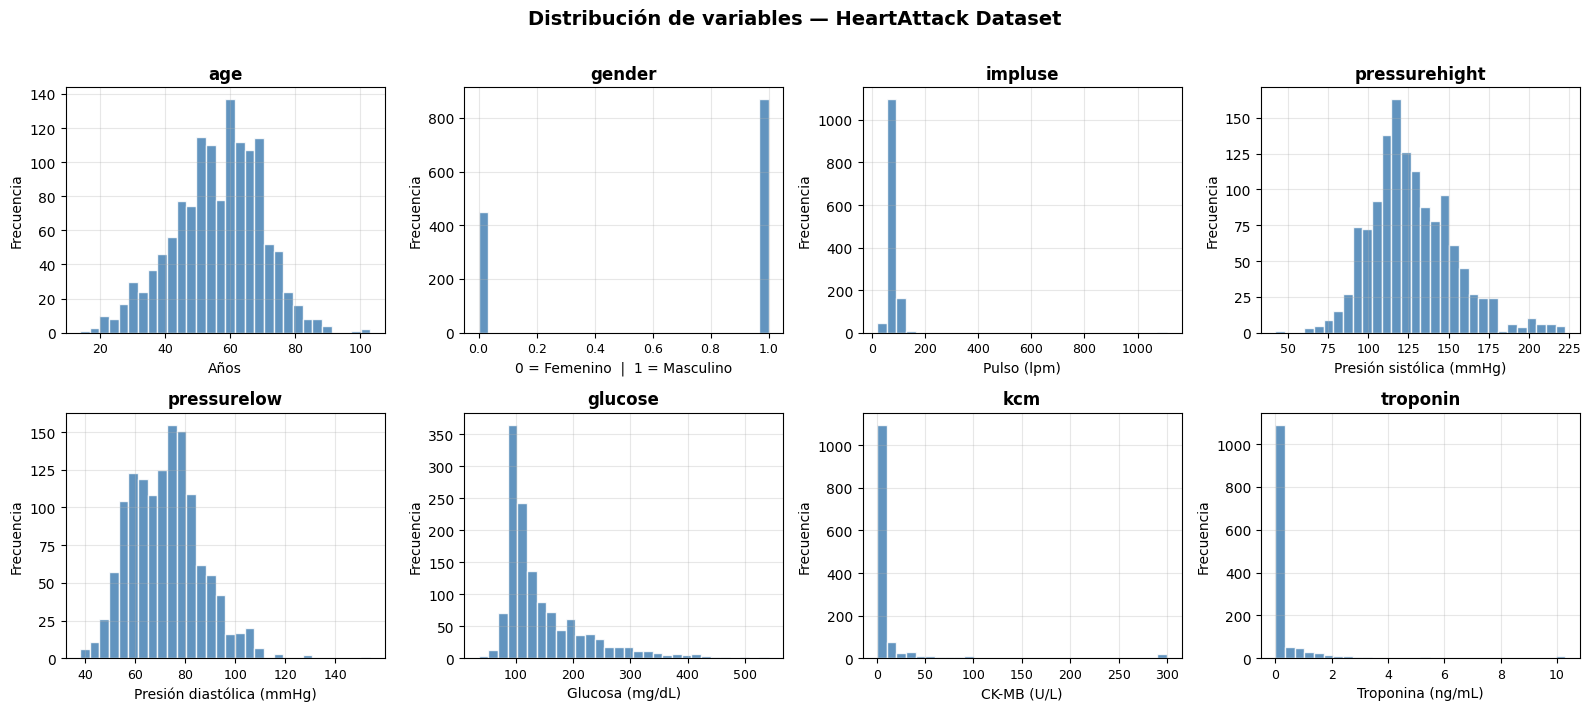

In [6]:
# ─── Distribución de variables numéricas ─────────────────────────────────────
etiquetas = {
    'age':           'Años',
    'gender':        '0 = Femenino  |  1 = Masculino',
    'impluse':       'Pulso (lpm)',
    'pressurehight': 'Presión sistólica (mmHg)',
    'pressurelow':   'Presión diastólica (mmHg)',
    'glucose':       'Glucosa (mg/dL)',
    'kcm':           'CK-MB (U/L)',
    'troponin':      'Troponina (ng/mL)',
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(etiquetas.get(col, col), fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].tick_params(axis='x', labelsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribución de variables — HeartAttack Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figuras/Distribución de variables — HeartAttack Datasets', dpi=150, bbox_inches='tight')
plt.show()

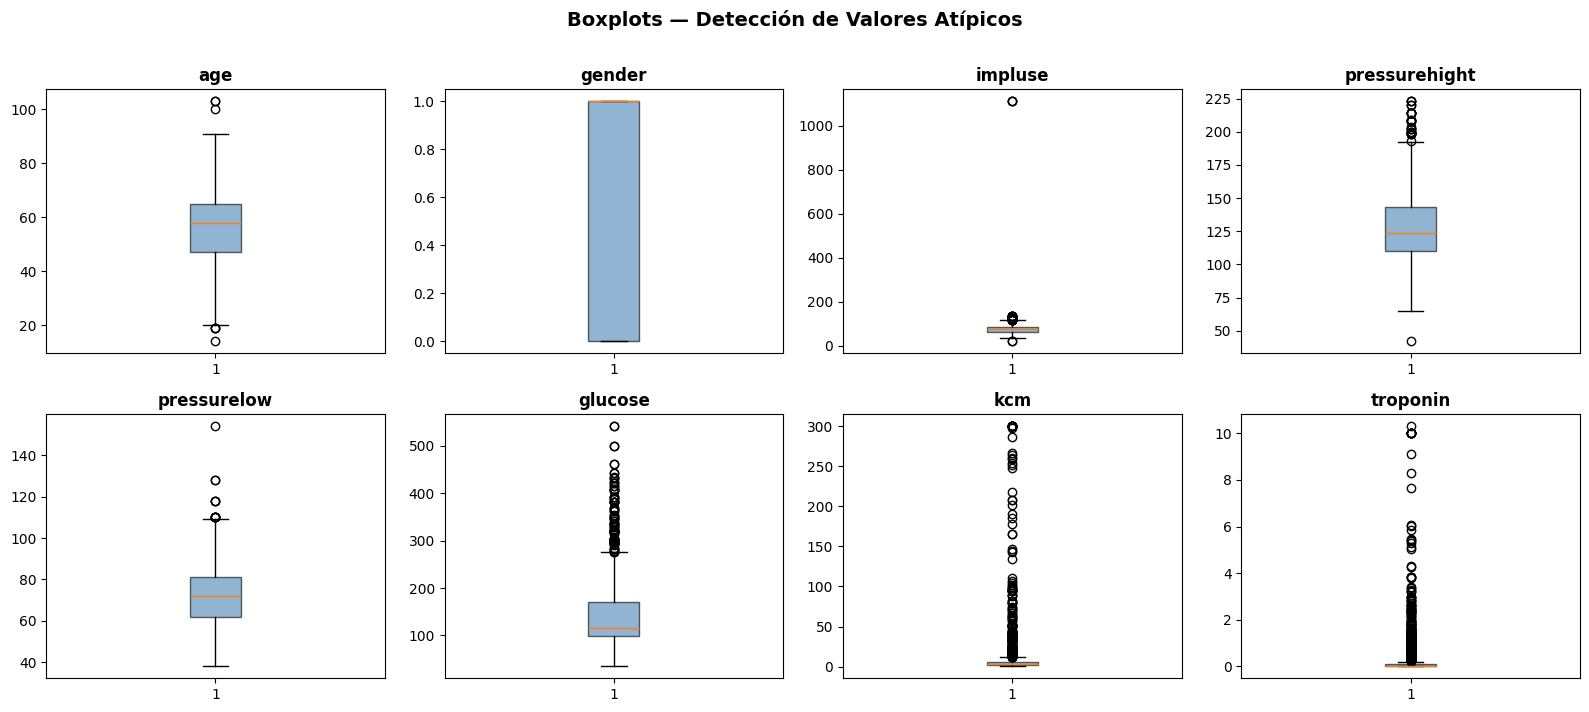

In [7]:
# ─── Boxplots para detección de outliers ─────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=12, fontweight='bold')

plt.suptitle('Boxplots — Detección de Valores Atípicos', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figuras/Boxplots — Detección de Valores Atípicos', dpi=150, bbox_inches='tight')
plt.show()

Se observan algunos outliers. Estos pueden siginifcar dos cosas, errores en medicion o verdaderos pacientes con algun problema.

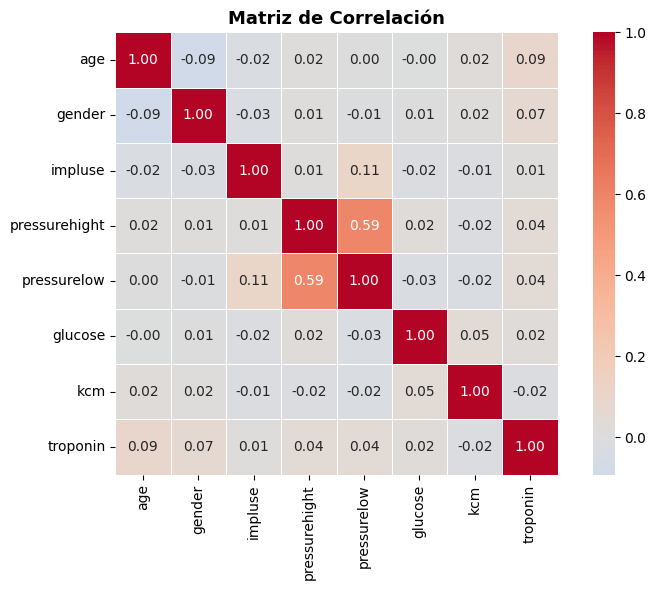

In [8]:
# ─── Matriz de correlación ───────────────────────────────────────────────────
plt.figure(figsize=(8, 6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Matriz de Correlación', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('figuras/Matriz de Correlación', dpi=150, bbox_inches='tight')
plt.show()

La única correlación relevante es pressurehight ↔ pressurelow (0.59) — tiene sentido fisiológico, la presión sistólica y diastólica suben y bajan juntas. 

### 1.1 Limpieza de Outliers

Se aplicará capping a los ouliers con bases fisiológicas, es decir, se colocarán umbrales considerados normales para los humanos.

In [9]:
limites_fisiologicos = {
    'age'          : (1,   110),   # años
    'impluse'      : (30,  200),   # bpm
    'pressurehight': (60,  300),   # mmHg sistólica
    'pressurelow'  : (30,  180),   # mmHg diastólica
}

df_clean = df.copy()
registros_afectados = []

for col, (lim_inf, lim_sup) in limites_fisiologicos.items():
    mask = (df_clean[col] < lim_inf) | (df_clean[col] > lim_sup)
    n_out = mask.sum()
    
    if n_out > 0:
        # Guardar registro de qué cambió
        afectados = df_clean.loc[mask, col].copy()
        for idx, val_original in afectados.items():
            registros_afectados.append({
                'indice'       : idx,
                'columna'      : col,
                'valor_original': val_original,
                'valor_nuevo'  : np.clip(val_original, lim_inf, lim_sup),
                'limite_inf'   : lim_inf,
                'limite_sup'   : lim_sup,
            })
        print(f"{col}: {n_out} valores fuera de rango → capping aplicado")

    df_clean[col] = df_clean[col].clip(lower=lim_inf, upper=lim_sup)

# DataFrame con el reporte completo
if registros_afectados:
    reporte_capping = pd.DataFrame(registros_afectados)
    print(f"\nTotal de valores modificados: {len(reporte_capping)}")
    display(reporte_capping)
else:
    print("\nNingún valor fuera de límites fisiológicos — datos limpios ✅")

df = df_clean.copy()

impluse: 5 valores fuera de rango → capping aplicado
pressurehight: 1 valores fuera de rango → capping aplicado

Total de valores modificados: 6


,indice,columna,valor_original,valor_nuevo,limite_inf,limite_sup
0,63,impluse,1111,200,30,200
1,708,impluse,20,30,30,200
2,717,impluse,1111,200,30,200
3,1060,impluse,20,30,30,200
4,1069,impluse,1111,200,30,200
5,209,pressurehight,42,60,60,300


In [10]:
df.describe().round(2)

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
count,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00,1319.00
mean,56.19,0.66,76.28,127.18,72.27,146.63,15.27,0.36
std,13.65,0.47,16.32,26.08,14.03,74.92,46.33,1.15
min,14.00,0.00,30.00,60.00,38.00,35.00,0.32,0.00
25%,47.00,0.00,64.00,110.00,62.00,98.00,1.65,0.01
50%,58.00,1.00,74.00,124.00,72.00,116.00,2.85,0.01
75%,65.00,1.00,85.00,143.00,81.00,169.50,5.80,0.09
max,103.00,1.00,200.00,223.00,154.00,541.00,300.00,10.30


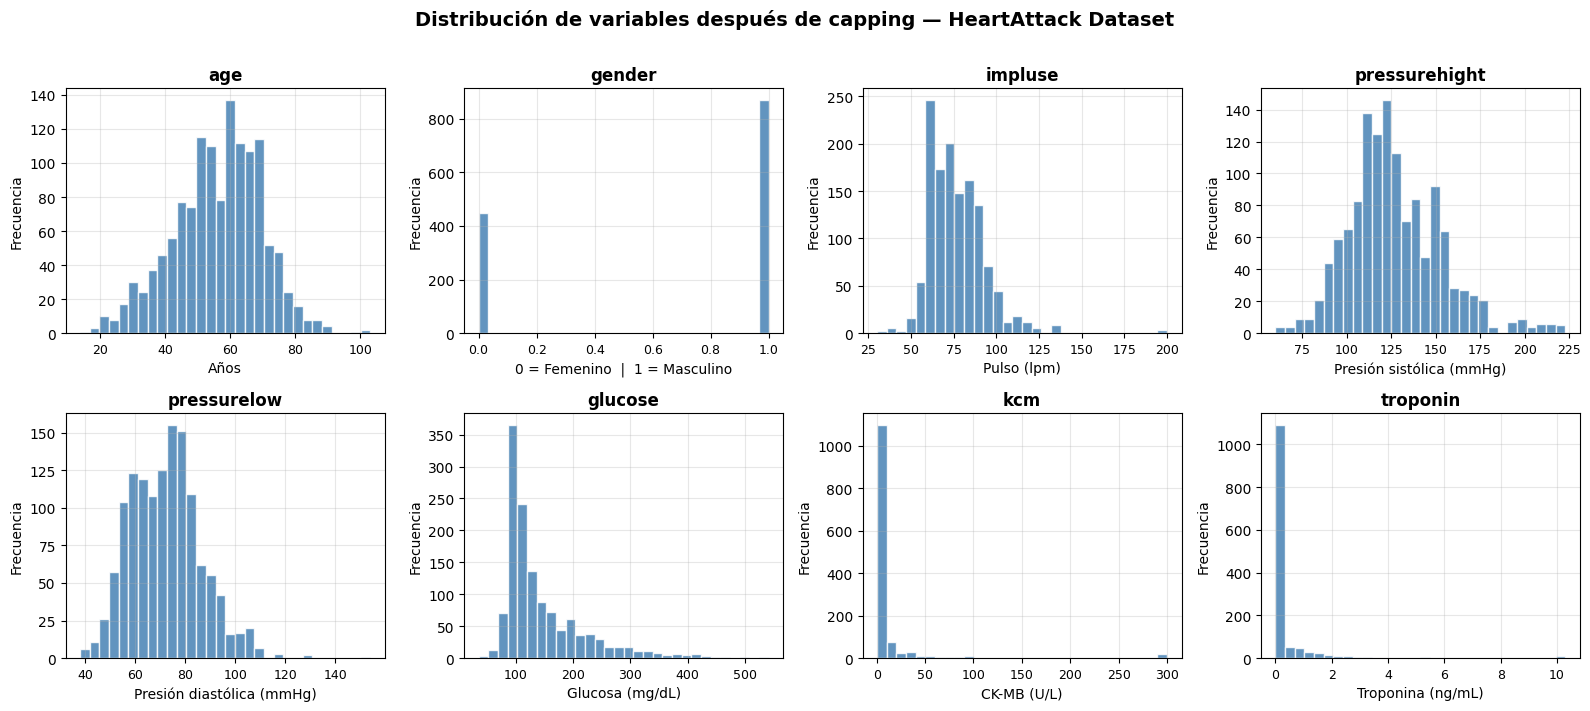

In [11]:
# ─── Distribución de variables numéricas despues de limpieza ─────────────────────────────────────
etiquetas = {
    'age':           'Años',
    'gender':        '0 = Femenino  |  1 = Masculino',
    'impluse':       'Pulso (lpm)',
    'pressurehight': 'Presión sistólica (mmHg)',
    'pressurelow':   'Presión diastólica (mmHg)',
    'glucose':       'Glucosa (mg/dL)',
    'kcm':           'CK-MB (U/L)',
    'troponin':      'Troponina (ng/mL)',
}

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(etiquetas.get(col, col), fontsize=10)
    axes[i].set_ylabel('Frecuencia', fontsize=10)
    axes[i].tick_params(axis='x', labelsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Distribución de variables después de capping — HeartAttack Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('figuras/Distribución de variables después de capping — HeartAttack Dataset', dpi=150, bbox_inches='tight')
plt.tight_layout()
plt.show()

### 1.2 Selección de características

**Variables excluidas:**
- `gender`: variable categórica binaria (0/1) con correlaciones bajas con el resto de variables; su inclusión en PCA podría distorsionar la escala.

**Variables incluidas:** `age`, `impluse`, `pressurehight`, `pressurelow`, `glucose`, `kcm`, `troponin`

Estas siete variables son biomarcadores fisiológicos continuos directamente relacionados con el riesgo cardiaco, y son las que aportan más varianza explicable al análisis.

In [12]:
# ─── Selección de características relevantes ─────────────────────────────────
features = ['age', 'impluse', 'pressurehight', 'pressurelow', 'glucose', 'kcm', 'troponin']
X = df[features].copy()

print(f'Shape del subconjunto de features: {X.shape}')

Shape del subconjunto de features: (1319, 7)


---
## 2. Reducción de Dimensiones con PCA



In [13]:
# ─── Escalado: estandarización z-score ───────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [14]:
def varianza_explicada_2d(X_original, X_proj):
    """
    Calcula el % de varianza del espacio original explicado
    por cada dimensión de la proyección 2D.
    Solo interpretable para PCA y MDS; NO usar con t-SNE.
    """
    var_total = np.var(X_original, axis=0).sum()
    var_c1    = np.var(X_proj[:, 0])
    var_c2    = np.var(X_proj[:, 1])
    return var_c1 / var_total * 100, var_c2 / var_total * 100

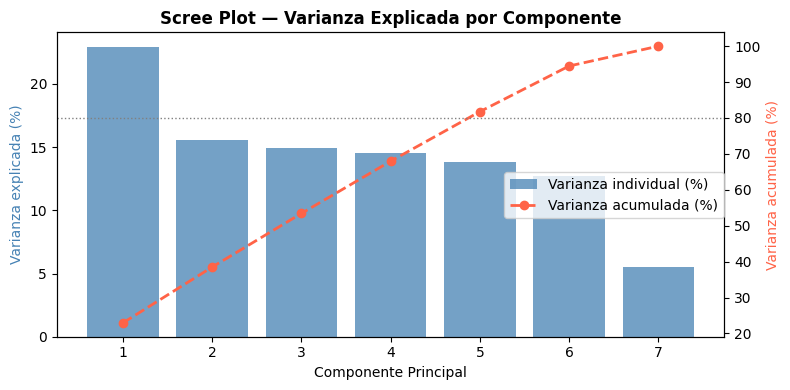

Varianza explicada por componente:
  PC1: 22.94%  (acumulada: 22.94%)
  PC2: 15.55%  (acumulada: 38.48%)
  PC3: 14.94%  (acumulada: 53.43%)
  PC4: 14.53%  (acumulada: 67.96%)
  PC5: 13.80%  (acumulada: 81.76%)
  PC6: 12.71%  (acumulada: 94.47%)
  PC7: 5.53%  (acumulada: 100.00%)


In [15]:
# ─── PCA con todas las componentes (para el scree plot) ──────────────────────
pca_full = PCA(random_state=random_seed)
pca_full.fit(X_scaled)

varianza_explicada = pca_full.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza_explicada)

# Scree plot
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.bar(range(1, len(varianza_explicada)+1), varianza_explicada * 100,
        color='steelblue', alpha=0.75, label='Varianza individual (%)')
ax2 = ax1.twinx()
ax2.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada * 100,
         'o--', color='tomato', linewidth=2, label='Varianza acumulada (%)')
ax2.axhline(80, linestyle=':', color='gray', linewidth=1)
ax1.set_xlabel('Componente Principal')
ax1.set_ylabel('Varianza explicada (%)', color='steelblue')
ax2.set_ylabel('Varianza acumulada (%)', color='tomato')
ax1.set_title('Scree Plot — Varianza Explicada por Componente', fontweight='bold')
fig.legend(loc='center right', bbox_to_anchor=(0.92, 0.5))
plt.tight_layout()
plt.show()

print('Varianza explicada por componente:')
for i, (v, vc) in enumerate(zip(varianza_explicada, varianza_acumulada), 1):
    print(f'  PC{i}: {v*100:.2f}%  (acumulada: {vc*100:.2f}%)')

In [16]:
# ─── PCA a 2 componentes ──────────────────────────────────────────────────────
pca = PCA(n_components=2, random_state=random_seed)
X_pca = pca.fit_transform(X_scaled)

# DataFrame con las 2 componentes
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

print(f'Varianza explicada — PC1: {pca.explained_variance_ratio_[0]*100:.2f}%, '
      f'PC2: {pca.explained_variance_ratio_[1]*100:.2f}%')
print(f'Total capturado en 2D: {pca.explained_variance_ratio_.sum()*100:.2f}%')

Varianza explicada — PC1: 22.94%, PC2: 15.55%
Total capturado en 2D: 38.48%


In [17]:
# ─── Loadings — contribución de cada variable a PC1 y PC2 ────────────────────
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=['PC1', 'PC2']
).round(3)

print('Loadings (contribución de variables a cada componente):')
print(loadings)

Loadings (contribución de variables a cada componente):
                 PC1    PC2
age            0.037  0.671
impluse        0.130  0.122
pressurehight  0.686 -0.078
pressurelow    0.704 -0.078
glucose       -0.006  0.214
kcm           -0.050  0.155
troponin       0.114  0.673


---
### 2.1 Segmentación del Espacio Reducido

**Criterio utilizado:** umbral en PC1.

Dado que PC1 captura la mayor parte de la varianza (~XX%) y los loadings muestran que **kcm** y **troponin** tienen las cargas más altas en esta componente, un valor positivo de PC1 indica niveles elevados de estos biomarcadores cardiacos. Se usa el umbral **PC1 > 2** para separar los pacientes con valores extremos en biomarcadores de riesgo del resto.

Distribución de grupos:
grupo
Riesgo Bajo    1202
Alto Riesgo     117
Name: count, dtype: int64

Proporción Alto Riesgo: 8.9%


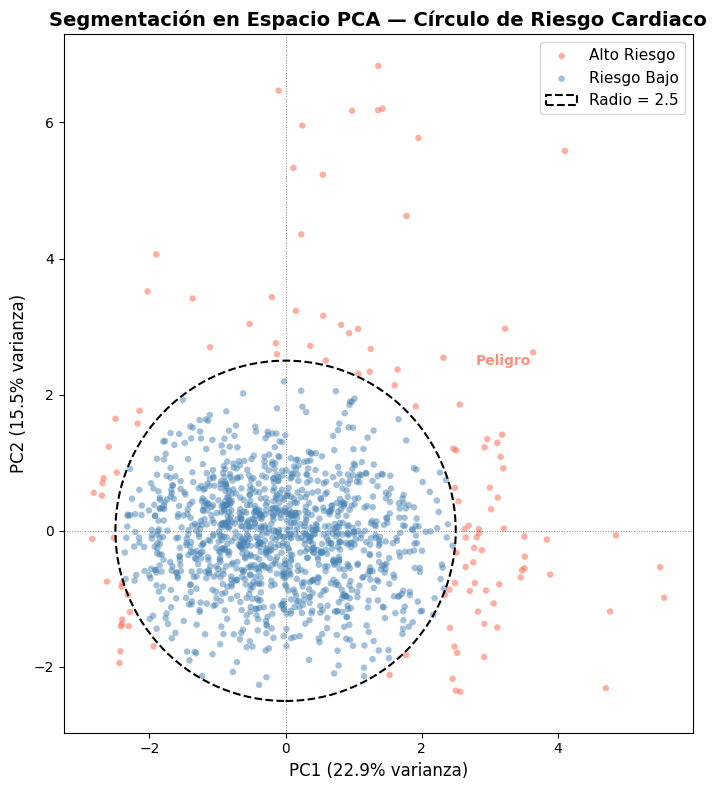

In [18]:
# ─── Definición del umbral de segmentación — círculo en el origen ─────────────
RADIO = 2.5  # Pacientes fuera del círculo = Alto Riesgo

# Distancia euclidiana de cada punto al origen (0, 0)
df_pca['distancia'] = np.sqrt(df_pca['PC1']**2 + df_pca['PC2']**2)
df_pca['grupo'] = np.where(df_pca['distancia'] > RADIO, 'Alto Riesgo', 'Riesgo Bajo')

conteo = df_pca['grupo'].value_counts()
print('Distribución de grupos:')
print(conteo)
print(f'\nProporción Alto Riesgo: {conteo["Alto Riesgo"]/len(df_pca)*100:.1f}%')

# ─── Visualización ────────────────────────────────────────────────────────────
colores = {'Alto Riesgo': 'tomato', 'Riesgo Bajo': 'steelblue'}

fig, ax = plt.subplots(figsize=(9, 8))

for grupo, color in colores.items():
    mask = df_pca['grupo'] == grupo
    ax.scatter(df_pca.loc[mask, 'PC1'], df_pca.loc[mask, 'PC2'],
               alpha=0.5, s=22, color=color, label=grupo, edgecolors='none')

# Círculo de separación
circulo = plt.Circle((0, 0), RADIO,
                     color='black', fill=False,
                     linestyle='--', linewidth=1.5,
                     label=f'Radio = {RADIO}')
ax.add_patch(circulo)

# Ejes de referencia
ax.axvline(x=0, color='gray', linestyle=':', linewidth=0.7)
ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.7)

# Etiquetas de zona
ax.text(0, 0, 'Normal', fontsize=10, color='steelblue',
        ha='center', va='center', fontweight='bold', alpha=0.4)
ax.text(3.2, 2.5, 'Peligro', fontsize=10, color='tomato',
        ha='center', va='center', fontweight='bold', alpha=0.7)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)', fontsize=12)
ax.set_title('Segmentación en Espacio PCA — Círculo de Riesgo Cardiaco',
             fontsize=14, fontweight='bold')
ax.set_aspect('equal')  # importante para que el círculo no se deforme
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figuras/Segmentación en Espacio PCA — Círculo de Riesgo Cardiaco', dpi=150, bbox_inches='tight')
plt.show()


---
### 2.2 Análisis por Grupo

In [19]:
# ─── Agregar grupo al dataframe original ─────────────────────────────────────
df_analisis = df[features].copy()
df_analisis['grupo'] = df_pca['grupo'].values

# Estadísticas por grupo
resumen = df_analisis.groupby('grupo').agg(['mean', 'median', 'std']).round(3)


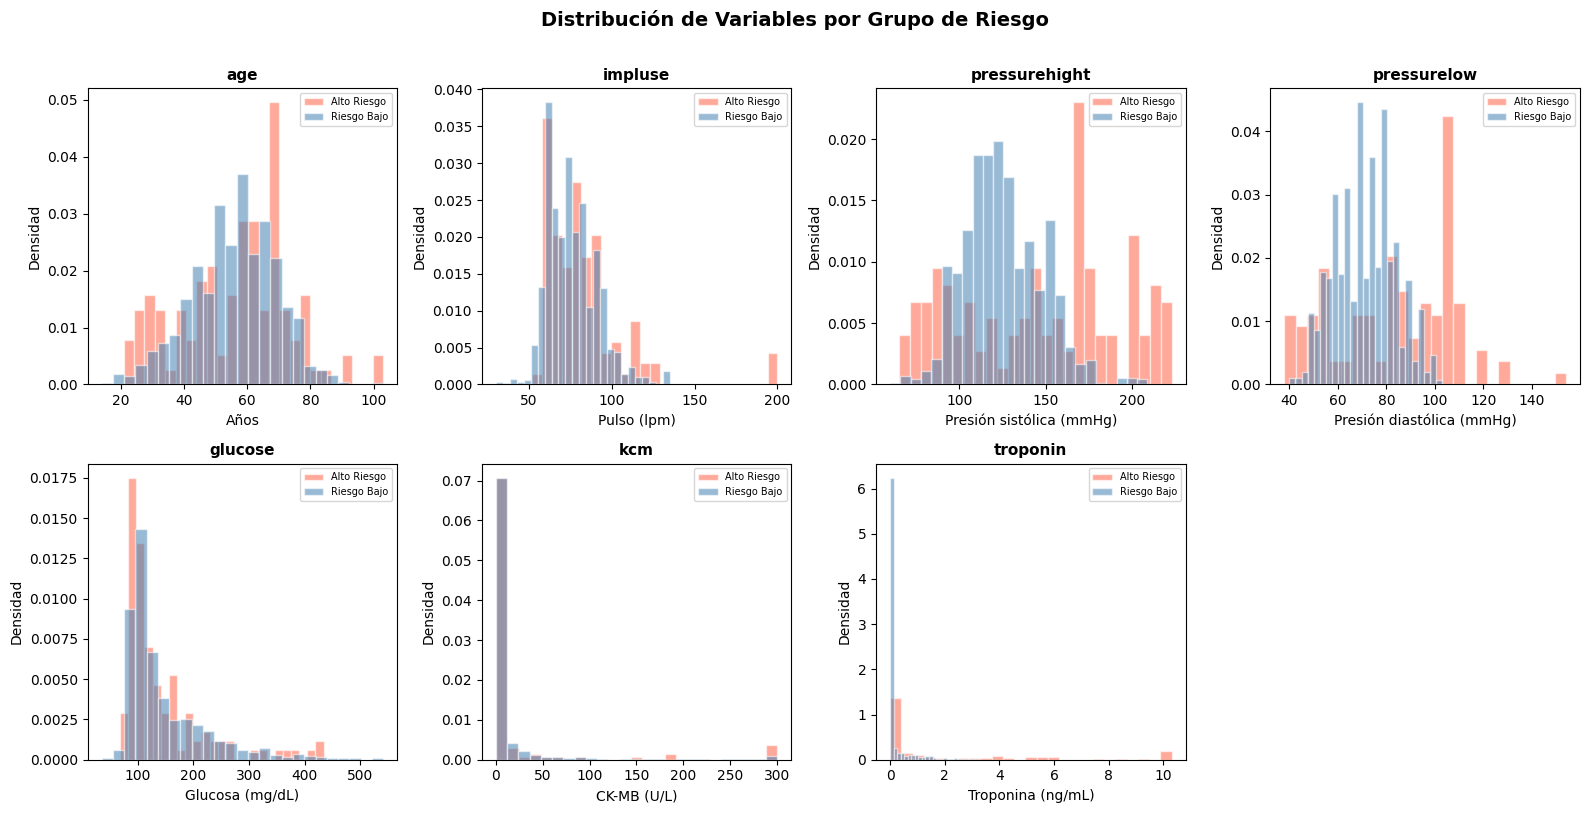

In [20]:
# ─── Comparación visual de distribuciones por grupo ──────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    for grupo, color in colores.items():
        datos = df_analisis.loc[df_analisis['grupo'] == grupo, col]
        axes[i].hist(datos, bins=25, alpha=0.55, color=color,
                     label=grupo, edgecolor='white', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Densidad')
    axes[i].legend(fontsize=7)
    axes[i].set_xlabel(etiquetas.get(col, col), fontsize=10)

# Ocultar el último subplot vacío
axes[-1].set_visible(False)

plt.suptitle('Distribución de Variables por Grupo de Riesgo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
### 2.3 Conclusiones PCA

PCA no es optimo para este analisis debido a que no hay linealidad entre las componentes. Las primeras dos componentes apenas sitenian un 38% de varianza explicada.

---
## 3. Reducción de Dimensiones con MDS Métrico

**MDS Métrico** (Multidimensional Scaling métrico) preserva distancias euclidianas del espacio original, proyectando los datos en 2D minimizando el *stress* entre distancias reales y proyectadas.

In [ ]:
from sklearn.manifold import MDS

# ─── MDS Métrico ──────────────────────────────────────────────────────────────
print('Ejecutando MDS Métrico...')
mds_metrico = MDS(n_components=2, metric=True, random_state=random_seed)
X_mds_m = mds_metrico.fit_transform(X_scaled)
print(f'Forma resultante: {X_mds_m.shape}')

Ejecutando MDS Métrico...


c:\Users\Hin-j\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\manifold\_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


### 3.1 Calidad de la Proyección

El **stress** mide qué tan bien se preservan las distancias originales en el espacio proyectado. Interpretación orientativa:
- Stress < 0.05 → excelente
- Stress < 0.10 → bueno
- Stress < 0.20 → aceptable
- Stress > 0.20 → cuestionable

In [ ]:
# ─── Stress MDS Métrico (normalizado — escala Kruskal 1964) ──────────────────
# sklearn devuelve stress sin normalizar (suma de errores²);
# dividimos por la suma de distancias² originales para obtener stress ∈ [0, 1]
stress_raw        = mds_metrico.stress_
stress_normalizado = np.sqrt(stress_raw / np.sum(X_scaled ** 2))

print(f'Stress raw (sklearn):   {stress_raw:.2f}')
print(f'Stress normalizado:     {stress_normalizado:.4f}')

niveles = [(0.05, 'Excelente'), (0.10, 'Bueno'), (0.20, 'Aceptable')]
calidad = 'Cuestionable'
for umbral, label in niveles:
    if stress_normalizado < umbral:
        calidad = label
        break
print(f'Calidad (Kruskal):      {calidad}')

Stress raw (sklearn):   686763.20
Stress normalizado:     8.6245
Calidad (Kruskal):      Cuestionable


### 3.1b Diagrama de Shepard

El **diagrama de Shepard** compara las distancias originales (alta dimensión) con las distancias en el espacio reducido (2D). 

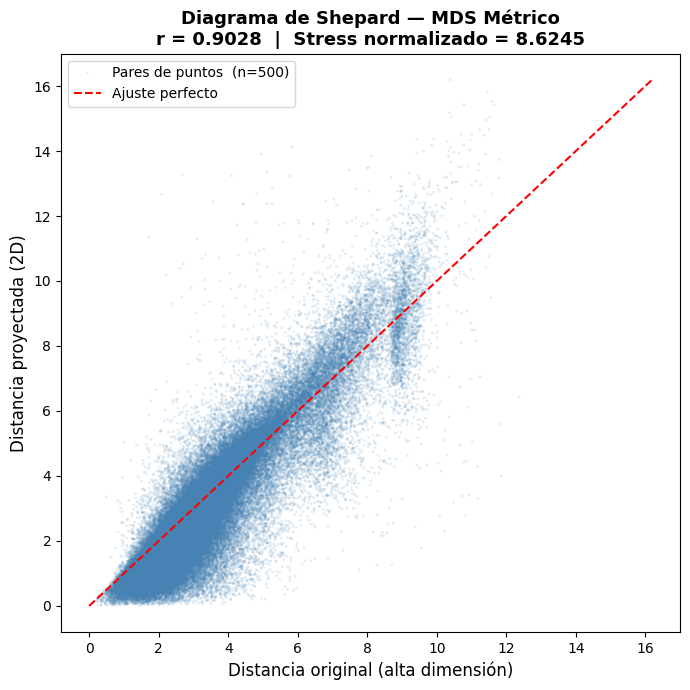

Correlación de Pearson (dist. orig. vs 2D): 0.9028
Stress normalizado (Kruskal):               8.6245


In [ ]:
# ─── Diagrama de Shepard — MDS Métrico ────────────────────────────────────────
from sklearn.metrics import pairwise_distances

# Muestra aleatoria para no saturar el gráfico (máx. 500 puntos)
rng = np.random.default_rng(random_seed)
n_sample = min(500, len(X_scaled))
idx = rng.choice(len(X_scaled), size=n_sample, replace=False)

# Distancias originales (alta dimensión) y proyectadas (2D)
dist_orig = pairwise_distances(X_scaled[idx], metric='euclidean')
dist_2d   = pairwise_distances(X_mds_m[idx],  metric='euclidean')

# Solo triángulo superior (sin diagonal)
mask = np.triu(np.ones_like(dist_orig, dtype=bool), k=1)
d_orig_flat = dist_orig[mask]
d_2d_flat   = dist_2d[mask]

# Correlación de Pearson como medida adicional de fidelidad
r = np.corrcoef(d_orig_flat, d_2d_flat)[0, 1]

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(d_orig_flat, d_2d_flat,
           alpha=0.15, s=4, color='steelblue', edgecolors='none',
           label=f'Pares de puntos  (n={n_sample})')

# Línea de referencia ideal (diagonal)
lims = [0, max(d_orig_flat.max(), d_2d_flat.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Ajuste perfecto')

ax.set_xlabel('Distancia original (alta dimensión)', fontsize=12)
ax.set_ylabel('Distancia proyectada (2D)',            fontsize=12)
ax.set_title(f'Diagrama de Shepard — MDS Métrico\n'
             f'r = {r:.4f}  |  Stress normalizado = {stress_normalizado:.4f}',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Correlación de Pearson (dist. orig. vs 2D): {r:.4f}')
print(f'Stress normalizado (Kruskal):               {stress_normalizado:.4f}')

### 3.2 Visualización con Grupos de Riesgo


Radio de separación: 3.719
Distribución de grupos (MDS Métrico):
Riesgo Bajo    1187
Alto Riesgo     132
Name: count, dtype: int64


ValueError: Format '72)' is not supported (supported formats: eps, jpeg, jpg, pdf, pgf, png, ps, raw, rgba, svg, svgz, tif, tiff, webp)

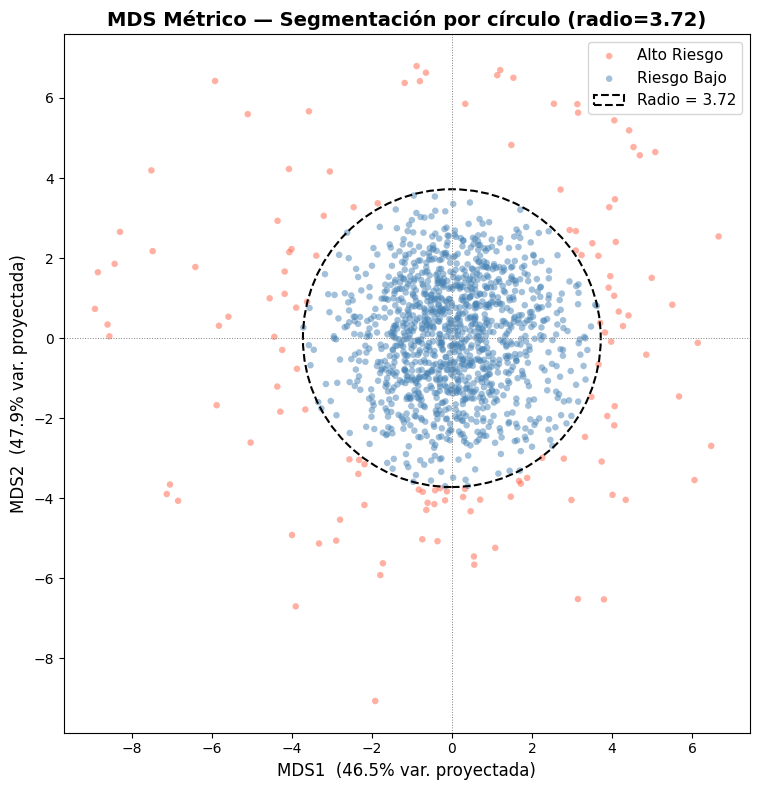

In [ ]:
# ─── Segmentación MDS Métrico — círculo centrado en el origen ─────────────────
dist_mds  = np.sqrt(X_mds_m[:, 0]**2 + X_mds_m[:, 1]**2)
RADIO_MDS = np.percentile(dist_mds, 90)  # top 10% = Alto Riesgo

grupo_mds_m = np.where(dist_mds > RADIO_MDS, 'Alto Riesgo', 'Riesgo Bajo')

conteo_mds_m = pd.Series(grupo_mds_m).value_counts()
print(f'Radio de separación: {RADIO_MDS:.3f}')
print('Distribución de grupos (MDS Métrico):')
print(conteo_mds_m)

# ─── Visualización ────────────────────────────────────────────────────────────
p1, p2 = varianza_explicada_2d(X_scaled, X_mds_m)

fig, ax = plt.subplots(figsize=(9, 8))

for grupo, color in colores.items():
    mask = grupo_mds_m == grupo
    ax.scatter(X_mds_m[mask, 0], X_mds_m[mask, 1],
               alpha=0.5, s=22, color=color, label=grupo, edgecolors='none')

# Círculo de separación
circulo = plt.Circle((0, 0), RADIO_MDS,
                     color='black', fill=False,
                     linestyle='--', linewidth=1.5,
                     label=f'Radio = {RADIO_MDS:.2f}')
ax.add_patch(circulo)

# Ejes de referencia
ax.axvline(x=0, color='gray', linestyle=':', linewidth=0.7)
ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.7)


ax.set_xlabel(f'MDS1  ({p1:.1f}% var. proyectada)', fontsize=12)
ax.set_ylabel(f'MDS2  ({p2:.1f}% var. proyectada)', fontsize=12)
ax.set_title(f'MDS Métrico — Segmentación por círculo (radio={RADIO_MDS:.2f})',
             fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figuras/MDS Métrico — Segmentación por círculo', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Conclusiones MDS Métrico

MDS Métrico logra concentrar el 94% de la varianza proyectada en dos componentes, lo que indica una proyección bien distribuida en el plano. Sin embargo, el stress elevado sugiere que las distancias euclidianas originales en el espacio de 7 dimensiones no se preservan fielmente — probablemente porque la estructura del dataset no es bien representable en 2D con distancias exactas. Esto es consistente con la baja correlación entre variables observada en la matriz de correlación.

---
## 4. Reducción de Dimensiones con t-SNE

**t-SNE** (t-Distributed Stochastic Neighbor Embedding) es un método no lineal que prioriza preservar la estructura local de los datos, ideal para visualizar agrupamientos. 

### 4.0 Estimación de la Perplejidad Óptima

Antes de ejecutar t-SNE, estimamos la **perplejidad óptima** usando el método del **codo** (*knee*) en la curva de distancias k-NN 

- La curva muestra la distancia media al k-ésimo vecino en el espacio original escalado.
- El codo marca el punto donde agregar más vecinos aporta poca información adicional.
- Ese k se usa como perplejidad de partida para t-SNE.

In [ ]:
Xr = StandardScaler().fit_transform(X)

In [ ]:
import plotly.graph_objects as go
def estimate_neighbors_knee(Xmat, metric='euclidean', kmax=60,
                            sample_max=2000, random_state=0):
    rng = np.random.default_rng(random_state)
    n = Xmat.shape[0]
    kmax = int(min(kmax, max(5, n-1)))

    # Submuestreo si n es grande
    if n > sample_max:
        idx = rng.choice(n, size=sample_max, replace=False)
        Xs = Xmat[idx]
    else:
        Xs = Xmat

    nbrs = NearestNeighbors(n_neighbors=min(kmax+1, Xs.shape[0]),
                            metric=metric).fit(Xs)
    dists, _ = nbrs.kneighbors(Xs, return_distance=True)
    dists = dists[:, 1:]                      # quitamos la distancia a sí mismo
    mean_k = np.mean(dists, axis=0)           # promedio por k
    ylog = np.log(mean_k + 1e-12)

    # Suavizado simple (media móvil)
    def movavg(a, w=5):
        if len(a) < w: return a
        return np.convolve(a, np.ones(w)/w, mode='same')

    y_s = movavg(ylog, w=5)

    # 2d derivada discreta para detectar el codo
    d2 = np.zeros_like(y_s)
    d2[1:-1] = y_s[:-2] - 2*y_s[1:-1] + y_s[2:]

    knee_k = int(np.argmax(d2[2:]) + 2 + 1)
    # Clip a [5,50] y <= n/3
    knee_k = int(np.clip(knee_k, 5, 50))
    knee_k = int(min(knee_k, max(5, Xmat.shape[0]//3)))
    return knee_k, mean_k

def plot_knee_curve(k_curve, pp_hat,
                    pp_candidates, template="plotly_dark"):
    k_vals = np.arange(1, len(k_curve)+1)
    y = np.log(k_curve + 1e-12)

    fig = go.Figure()

    # Curva log(distancia k-NN promedio) vs k
    fig.add_trace(go.Scatter(
        x=k_vals, y=y,
        mode='lines+markers',
        name='log distancia k-NN promedio',
        hovertemplate="k=%{x}<br>log(dist_kNN)=%{y:.4f}<extra></extra>"
    ))

    # Línea vertical en el knee (pp_hat)
    fig.add_vline(
        x=pp_hat,
        line_width=2,
        line_dash='dash',
        line_color='red',
        annotation_text=f"knee ≈ {pp_hat}",
        annotation_position="top"
    )

    # Marcas de las perplejidades candidatas
    fig.add_trace(go.Scatter(
        x=pp_candidates,
        y=[y[k-1] for k in pp_candidates],
        mode='markers',
        marker=dict(size=12, symbol='diamond', color='orange'),
        name='perplejidades candidatas',
        hovertemplate="k=%{x}<br>log(dist_kNN)=%{y:.4f}<extra></extra>"
    ))
    fig.update_layout(
        title=f"Curva knee para proponer perplejidad (kmax={len(k_curve)})",
        xaxis_title="k vecinos",
        yaxis_title="log distancia k-NN promedio",
        hovermode="x"
    )

    return fig

In [ ]:
pp_hat, k_curve = estimate_neighbors_knee(Xr, metric='euclidean',
                                          kmax=50,
                                          random_state=random_seed)

pp_hat = 15

pp_candidates = sorted(set([max(5, pp_hat-8), pp_hat, min(50, pp_hat+8)]))

fig = plot_knee_curve(k_curve, pp_hat, pp_candidates)
fig.write_image('knee_curve.png')
fig.show()

NOTE: Se tomo 15 de perplejidad debido a que con 5 (resultado original), no se percibia una agrupacion significativa

In [ ]:


# ─── t-SNE con perplejidad estimada e inicialización PCA ─────────────────────
print(f'Ejecutando t-SNE  |  perplexity={pp_hat}  |  init=pca  |  max_iter=1000...')
t0   = time()
tsne = TSNE(n_components=2, perplexity=pp_hat, learning_rate='auto',
            init='pca', max_iter=1000, random_state=random_seed)
X_tsne = tsne.fit_transform(X_scaled)
t1   = time()
print(f'Forma resultante : {X_tsne.shape}')
print(f'Tiempo de cómputo: {t1 - t0:.1f} s')

Ejecutando t-SNE  |  perplexity=15  |  init=pca  |  max_iter=1000...
Forma resultante : (1319, 2)
Tiempo de cómputo: 3.3 s


### 4.1 Calidad de la Proyección




In [ ]:
from sklearn.manifold import trustworthiness

k_eval = 10   # vecinos para métricas de calidad

# ─── Divergencia KL ───────────────────────────────────────────────────────────
print(f'Divergencia KL t-SNE : {tsne.kl_divergence_:.4f}')
print(f'Perplejidad utilizada : {tsne.perplexity}')

# ─── Trustworthiness ──────────────────────────────────────────────────────────
# ¿Los k vecinos más cercanos en 2D también lo eran en alta dimensión?
trust = trustworthiness(X_scaled, X_tsne, n_neighbors=k_eval)

# ─── Continuity ───────────────────────────────────────────────────────────────
# Dirección inversa: ¿vecinos en alta-D se preservan en 2D?
cont  = trustworthiness(X_tsne, X_scaled, n_neighbors=k_eval)

# ─── kNN-Jaccard ──────────────────────────────────────────────────────────────
def knn_jaccard(X_high, X_low, k=10):
    """Jaccard promedio entre conjuntos de k-NN en ambos espacios."""
    nn_h = NearestNeighbors(n_neighbors=k + 1).fit(X_high)
    nn_l = NearestNeighbors(n_neighbors=k + 1).fit(X_low)
    _, idx_h = nn_h.kneighbors(X_high)
    _, idx_l = nn_l.kneighbors(X_low)
    scores = []
    for i in range(len(X_high)):
        s_h = set(idx_h[i, 1:])
        s_l = set(idx_l[i, 1:])
        scores.append(len(s_h & s_l) / len(s_h | s_l))
    return float(np.mean(scores))

jaccard = knn_jaccard(X_scaled, X_tsne, k=k_eval)

# ─── Resumen ──────────────────────────────────────────────────────────────────
print(f'── Métricas de calidad (k = {k_eval} vecinos) ──────────────────────')
print(f'  Trustworthiness : {trust:.4f}')
print(f'  Continuity      : {cont:.4f}')
print(f'  kNN-Jaccard     : {jaccard:.4f}')
print()
print('Interpretación:')
print('  Trustworthiness ≈ 1  →  los vecinos en 2D son reales en alta dimensión.')
print('  Continuity      ≈ 1  →  la vecindad en alta-D se mantiene en 2D.')
print('  kNN-Jaccard     ≈ 1  →  los conjuntos de vecinos son casi idénticos.')

Divergencia KL t-SNE : 1.2570
Perplejidad utilizada : 15
── Métricas de calidad (k = 10 vecinos) ──────────────────────
  Trustworthiness : 0.9775
  Continuity      : 0.9379
  kNN-Jaccard     : 0.3966

Interpretación:
  Trustworthiness ≈ 1  →  los vecinos en 2D son reales en alta dimensión.
  Continuity      ≈ 1  →  la vecindad en alta-D se mantiene en 2D.
  kNN-Jaccard     ≈ 1  →  los conjuntos de vecinos son casi idénticos.


### 4.2 Visualización con Grupos de Riesgo

Aplicamos los grupos PCA para verificar si t-SNE, que preserva estructura *local*, también agrupa los pacientes de alto riesgo. Tener en cuenta que los ejes de t-SNE **no tienen unidades interpretables** (rotaciones y escalas son arbitrarias).

**Observación:** t-SNE tiende a formar grupos compactos separados cuando hay estructura local coherente. Si los pacientes de alto riesgo (biomarcadores elevados) forman una isla separada, confirma que su perfil es localmente diferente. La separación visual aquí **no implica** que la distancia entre grupos sea proporcional a la diferencia real.

Riesgo Bajo    1218
Alto Riesgo     101
Name: count, dtype: int64


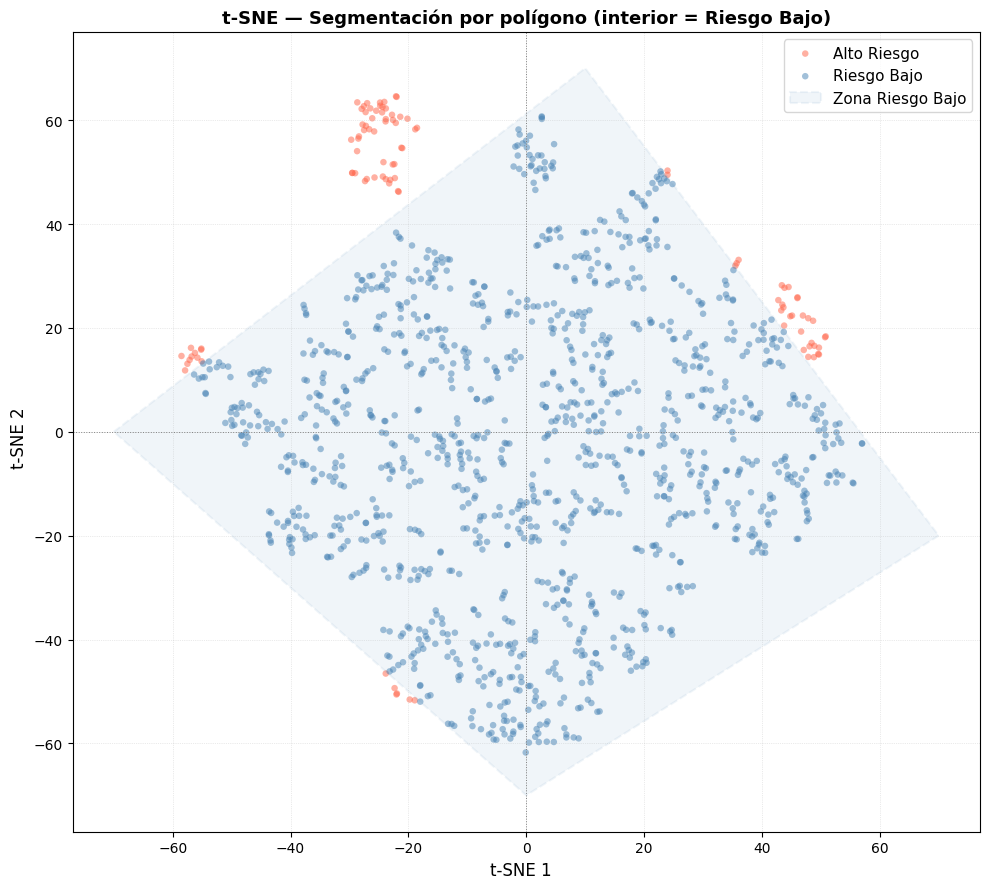

In [ ]:
from matplotlib.patches import Polygon
from matplotlib.path import Path

# ─── Vértices del polígono ────────────────────────────────────────────────────
vertices = np.array([
    [ -70,    0],
    [   10,  70],
    [   70,  -20],
    [    0, -70],
    [ -70,    0],   
])

# ─── Segmentación invertida: dentro = Riesgo Bajo ─────────────────────────────
path       = Path(vertices)
dentro     = path.contains_points(X_tsne)
grupo_tsne = np.where(dentro, 'Riesgo Bajo', 'Alto Riesgo')  

print(pd.Series(grupo_tsne).value_counts())



# ─── Visualización ────────────────────────────────────────────────────────────
colores_tsne = {'Alto Riesgo': 'tomato', 'Riesgo Bajo': 'steelblue'}

fig, ax = plt.subplots(figsize=(10, 9))

for grupo, color in colores_tsne.items():
    mask = grupo_tsne == grupo
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               alpha=0.5, s=22, color=color, label=grupo, edgecolors='none')

# Polígono — zona de Riesgo Bajo (interior)
poligono = Polygon(vertices[:-1], closed=True,
                   linewidth=1.5, linestyle='--',
                   edgecolor='steelblue', facecolor='steelblue', alpha=0.08,
                   label='Zona Riesgo Bajo')
ax.add_patch(poligono)

ax.axvline(x=0, color='gray', linestyle=':', linewidth=0.7)
ax.axhline(y=0, color='gray', linestyle=':', linewidth=0.7)
ax.grid(True, linestyle=':', linewidth=0.5, alpha=0.5)
ax.set_xlabel('t-SNE 1  ', fontsize=12)
ax.set_ylabel('t-SNE 2  ', fontsize=12)
ax.set_title('t-SNE — Segmentación por polígono',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('figuras/t-SNE — Segmentación por polígono', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ─── DataFrame con variables originales de Alto Riesgo ───────────────────────
df_alto_riesgo = df.loc[~dentro].reset_index(drop=True) 
print(f'\nPacientes Alto Riesgo: {len(df_alto_riesgo)}')
display(df_alto_riesgo)
df_alto_riesgo.to_csv("resultado_tsne.csv")


Pacientes Alto Riesgo: 101


,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
0,63,1,60,214,82,87.0,300.00,2.370
1,47,0,66,134,57,279.0,300.00,0.007
2,35,1,62,137,61,321.0,4.58,0.003
3,50,1,93,119,63,174.0,300.00,0.888
4,19,0,62,114,69,240.0,300.00,0.004
...,...,...,...,...,...,...,...,...
96,72,1,60,132,88,114.0,261.00,0.037
97,68,0,59,107,64,225.0,300.00,0.016
98,60,1,63,170,104,87.0,94.79,0.015
99,31,1,72,117,49,184.0,300.00,0.005


In [ ]:
df_alto_riesgo.describe()

,age,gender,impluse,pressurehight,pressurelow,glucose,kcm,troponin
count,101.000000,101.000000,101.000000,101.000000,101.00000,101.000000,101.000000,101.000000
mean,58.970297,0.673267,82.960396,131.623762,73.09901,154.118812,117.279683,0.397802
std,14.815840,0.471358,15.879497,31.376377,16.01843,74.652835,122.246735,1.509296
min,19.000000,0.000000,59.000000,65.000000,46.00000,61.000000,0.676000,0.003000
25%,53.000000,0.000000,70.000000,107.000000,61.00000,99.000000,3.100000,0.005000
50%,60.000000,1.000000,82.000000,130.000000,74.00000,121.000000,89.610000,0.013000
75%,68.000000,1.000000,93.000000,157.000000,83.00000,200.000000,254.400000,0.039000
max,91.000000,1.000000,135.000000,214.000000,107.00000,431.000000,300.000000,10.300000


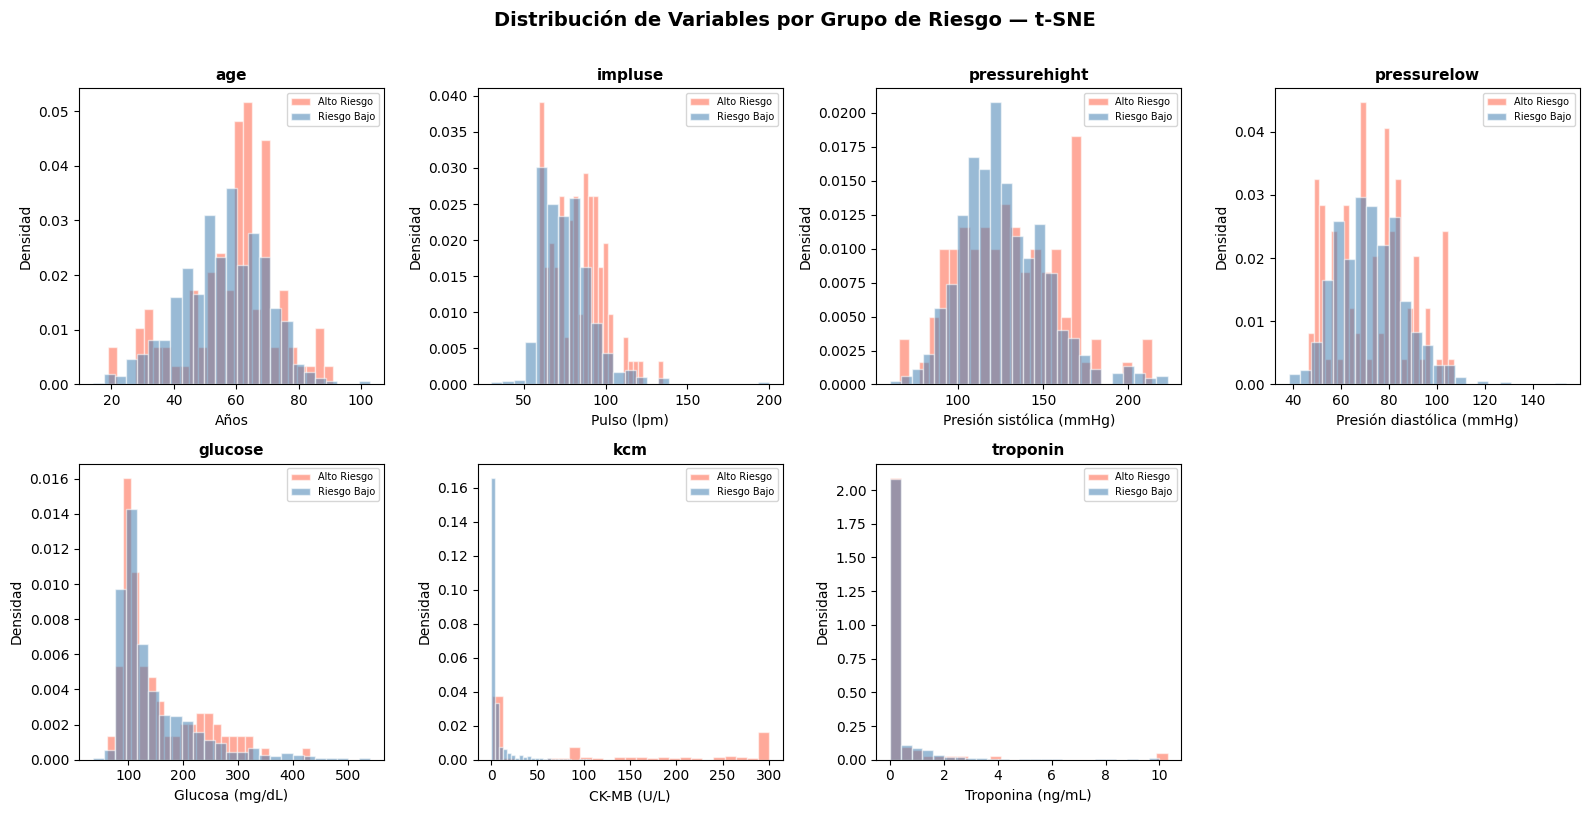

In [ ]:
# ─── DataFrame con variables originales + grupo t-SNE ────────────────────────
df_analisis_tsne = df[features].copy().reset_index(drop=True)
df_analisis_tsne['grupo'] = grupo_tsne  # grupos definidos por el polígono

# ─── Comparación visual de distribuciones por grupo ──────────────────────────
colores_tsne = {'Alto Riesgo': 'tomato', 'Riesgo Bajo': 'steelblue'}

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    for grupo, color in colores_tsne.items():
        datos = df_analisis_tsne.loc[df_analisis_tsne['grupo'] == grupo, col]
        axes[i].hist(datos, bins=25, alpha=0.55, color=color,
                     label=grupo, edgecolor='white', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Densidad')
    axes[i].set_xlabel(etiquetas.get(col, col), fontsize=10)
    axes[i].legend(fontsize=7)

axes[-1].set_visible(False)

plt.suptitle('Distribución de Variables por Grupo de Riesgo — t-SNE',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('figuras/Distribución de Variables por Grupo de Riesgo — t-SNE', dpi=150, bbox_inches='tight')

plt.show()

### 4.3 Conclusiones t-SNE

- t-SNE es el método más adecuado para revelar *clusters* naturales no lineales
- La divergencia KL confirma qué tan bien se preserva la vecindad local.
- El poligono de "personas saludables" es mas dificil de interpretar de forma visual.

In [ ]:
# Convertir a DataFrame y guardar
pd.DataFrame(X_mds_m,  columns=['MDS_m_1',  'MDS_m_2'] ).to_csv('X_mds_m.csv',  index=False)
pd.DataFrame(X_tsne,   columns=['tSNE_1',   'tSNE_2']  ).to_csv('X_tsne.csv',   index=False)

print("Archivos guardados correctamente ✅")

Archivos guardados correctamente ✅
